## Setup

In [ ]:
import pandas as pd
from tqdm.auto import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from ..analysis.helpers import (
    load_data,
    create_embeddings,
    build_graphs,
)
from ..analysis.analysis_helpers import analyze_centrality

tqdm.pandas()

## Old Data Loading + Embedding Creation

In [5]:
df = pd.read_csv("../outputs/hu_2017.csv")

,Speaker_ID,Date,ID,Text_ID,Title,Body,Term,Session,Meeting,Sitting,...,Party_status,Party_orientation,Speaker_name,Speaker_gender,Speaker_birth,Topic,Text,Full_text,label,score
0,AghPeter,2020-02-17,u2020-02-17-179-1,ParlaMint-HU_2020-02-17,"Hungarian parliamentary corpus ParlaMint-HU, l...",Unicameralism,8. ciklus,-,37. ülés,1. ülésnap,...,Coalition,Right to far-right,"Ágh, Péter",M,1982,Housing,Tisztelt Államtitkár Úr!,Tisztelt Államtitkár Úr! Magyarország Kormánya...,NEUTRAL,0.969221
1,AghPeter,2020-02-17,u2020-02-17-179-10,ParlaMint-HU_2020-02-17,"Hungarian parliamentary corpus ParlaMint-HU, l...",Unicameralism,8. ciklus,-,37. ülés,1. ülésnap,...,Coalition,Right to far-right,"Ágh, Péter",M,1982,Housing,"Emellett orvosi eszközök, falubuszok, közterül...",Tisztelt Államtitkár Úr! Magyarország Kormánya...,NEUTRAL,0.979289
2,AghPeter,2020-02-17,u2020-02-17-179-11,ParlaMint-HU_2020-02-17,"Hungarian parliamentary corpus ParlaMint-HU, l...",Unicameralism,8. ciklus,-,37. ülés,1. ülésnap,...,Coalition,Right to far-right,"Ágh, Péter",M,1982,Housing,"Látható, hogy az egyes alprogramok összefüggne...",Tisztelt Államtitkár Úr! Magyarország Kormánya...,NEUTRAL,0.985055
3,AghPeter,2020-02-17,u2020-02-17-179-12,ParlaMint-HU_2020-02-17,"Hungarian parliamentary corpus ParlaMint-HU, l...",Unicameralism,8. ciklus,-,37. ülés,1. ülésnap,...,Coalition,Right to far-right,"Ágh, Péter",M,1982,Housing,"Az érdeklődés óriási, a tapasztalatok jók, nek...",Tisztelt Államtitkár Úr! Magyarország Kormánya...,NEUTRAL,0.983033
4,AghPeter,2020-02-17,u2020-02-17-179-13,ParlaMint-HU_2020-02-17,"Hungarian parliamentary corpus ParlaMint-HU, l...",Unicameralism,8. ciklus,-,37. ülés,1. ülésnap,...,Coalition,Right to far-right,"Ágh, Péter",M,1982,Housing,A megvalósult fejlesztések mind az adott falut...,Tisztelt Államtitkár Úr! Magyarország Kormánya...,NEUTRAL,0.983119


In [ ]:
# TODO: Add helper-based embedding
df = create_embeddings(df)

## Data Loading

In [ ]:
# get the embeddings back
df = load_data(2020)

## Network Setup

### Network Construction

In [86]:
# extract the correct data from a timeframe
start = pd.Timestamp(year=2020, month=3, day=1)
end = pd.Timestamp(year=2021, month=1, day=1)

data = df.loc[(slice(None), slice(start, end)), :]
graphs = build_graphs(df, start, end, pd.offsets.MonthBegin(1), pd.offsets.MonthEnd(0))

Graph created for period 2020-04-01 00:00:00-2020-04-30 00:00:00
Graph created for period 2020-05-01 00:00:00-2020-05-31 00:00:00
Graph created for period 2020-06-01 00:00:00-2020-06-30 00:00:00
Graph created for period 2020-07-01 00:00:00-2020-07-31 00:00:00
Graph created for period 2020-08-01 00:00:00-2020-08-31 00:00:00
Graph created for period 2020-09-01 00:00:00-2020-09-30 00:00:00
Graph created for period 2020-10-01 00:00:00-2020-10-31 00:00:00
Graph created for period 2020-11-01 00:00:00-2020-11-30 00:00:00
Graph created for period 2020-12-01 00:00:00-2020-12-31 00:00:00
Graph created for period 2021-01-01 00:00:00-2021-01-31 00:00:00


## Network Visualizations

In [92]:
df.columns

Index(['Unnamed: 0', 'Text_ID', 'Title', 'Body', 'Term', 'Session', 'Meeting',
       'Sitting', 'Agenda', 'Subcorpus', 'Lang', 'Speaker_role', 'Speaker_MP',
       'Speaker_minister', 'Speaker_party', 'Speaker_party_name',
       'Party_status', 'Party_orientation', 'Speaker_name', 'Speaker_gender',
       'Speaker_birth', 'Topic', 'Text', 'Full_text', 'label', 'score',
       'embedding'],
      dtype='object')

In [129]:
from ipysigma import Sigma

G, sim_matrix, metrics = [
    (r["graph"], r["sim_matrix"], r["metrics"])
    for r in graphs
    if r["graph"] is not None
][3]

Sigma(
    G,
    node_size="degree_centrality",
    raw_node_color="opinion_color",
    node_border_color="Party_status",
    edge_size="weight",
    default_node_border_size=6,
)

Sigma(nx.Graph with 151 nodes and 2,924 edges)

In [126]:
analyze_centrality(G, "Graph")

                            Centrality measures of the largest connected component of Graph                            
           Degree            |         Betweenness         |          Closeness          |         Eigenvector         
  (NacsaLorinc)   - 0.753846 |  (NacsaLorinc)   - 0.058725 |  (NacsaLorinc)   - 0.783133 |  (NacsaLorinc)   - 0.133680
  (BoroczLaszlo)  - 0.707692 |  (VargaMihaly)   - 0.047729 |  (BoroczLaszlo)  - 0.751445 |  (BoroczLaszlo)  - 0.132314
  (OrbanBalazs)   - 0.684615 |   (SzucsLajos)   - 0.042853 |   (BankiErik)    - 0.747126 |  (OrbanBalazs)   - 0.131290
   (BankiErik)    - 0.676923 |  (FoldiLaszlo)   - 0.041887 |  (OrbanBalazs)   - 0.738636 | (VargaDammAndrea) - 0.131011
  (FoldiLaszlo)   - 0.653846 |   (BankiErik)    - 0.041055 |  (FoldiLaszlo)   - 0.734463 | (HarangozoTamas) - 0.130807
 (HarangozoTamas) - 0.653846 |   (NagyCsaba)    - 0.036385 | (HarangozoTamas) - 0.722222 | (LukacsLaszloGyorgy) - 0.130532



<Axes: ylabel='Count'>

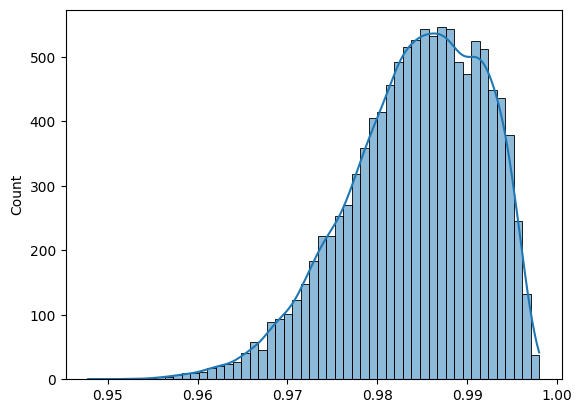

In [ ]:
# extract similarity scores
sim_flattened = []
for i in range(len(sim_matrix)):
    for j in range(i + 1, len(sim_matrix[i])):
        sim_flattened.append(sim_matrix[i, j])

# plot the distribution
sns.histplot(data=sim_flattened, kde=True)

In [132]:
list(metrics.keys())

['degree',
 'degree_centrality',
 'betweenness',
 'pagerank',
 'eigenvector',
 'communities',
 'modularity']

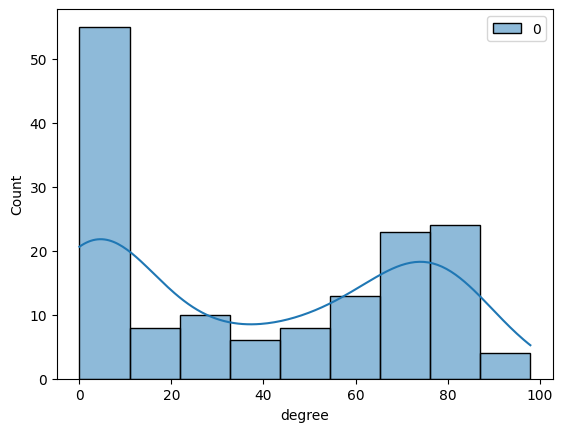

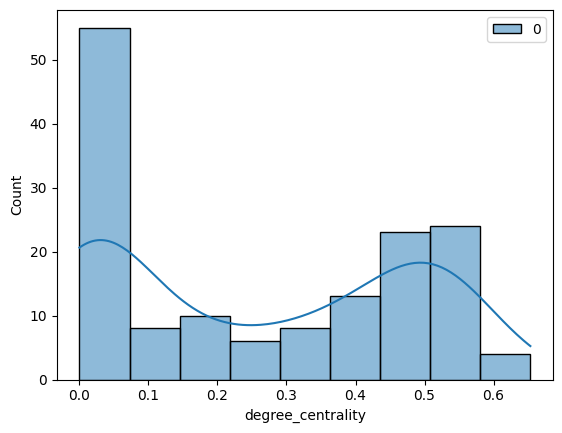

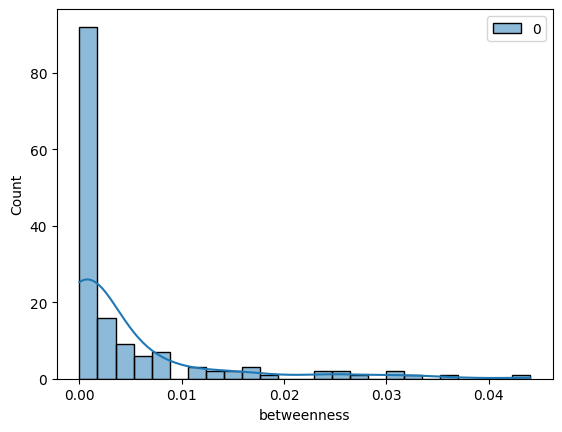

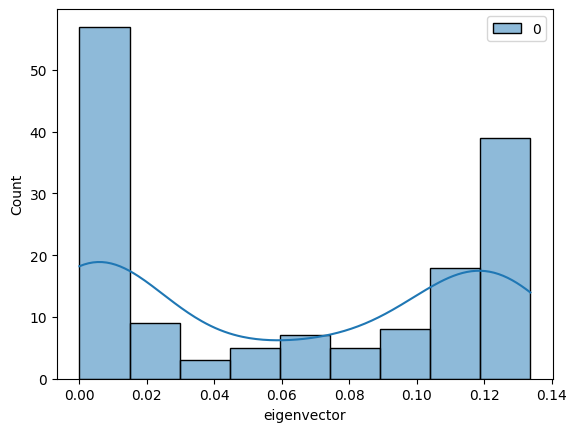

In [137]:
# get a few distributions of centralities
metric_names = ["degree", "degree_centrality", "betweenness", "eigenvector"]
for metric_name in metric_names:
    ax = sns.histplot(data=metrics[metric_name].values(), kde=True)
    ax.set(xlabel=metric_name)
    plt.show()